# **Data Visualization with Python**
---
Data visualization is an important tool in data analysis, as it allows you to easily understand and communicate complex information. In this tutorial, we will be using Python to visualize stock prices and perform some basic analysis. We will also explore the use of scatter plots in stock price analysis.


## **Step 1: Installation**
To begin, you will need to have Python and the following packages installed on your computer: pandas, matplotlib, and numpy. You can install them using pip, the package installer for Python. Open your command prompt or terminal and run the following commands:

In [ ]:
%%capture
!pip install pandas
!pip install matplotlib
!pip install numpy

## **Step 2: Importing the packages**
Now that you have the necessary packages installed, you can import them into your Python script.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## **Step 3: Retrieving Data**

To work with stock prices, you need to get the data first. We can use pandas to read data from a CSV file. But in this case, we will use Yahoo finance library to fetch the data.

In [ ]:
%%capture
!pip install yfinance

In [ ]:
import yfinance as yf

# Define the stock symbol
stock_symbol = "AAPL"

# Define the date range
start_date = "2020-01-01"
end_date = "2022-12-31"

# Download historical stock data
data = yf.download(stock_symbol, start=start_date, end=end_date)

# Print the stock data
data.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441452,146322800
2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200
2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000
2020-01-08,74.290001,76.110001,74.290001,75.797501,73.844353,132079200


## **Step 4: Data Cleaning**

Once you have the data, you will need to clean it up. This step is optional but is often necessary to ensure that your data is in a format that is easy to work with.

In [ ]:
# Remove any missing data
data = data.dropna()

## **Step 5: Plotting graphs**

### ***Line Plot***
Now that your data is clean and ready to use, you can start visualizing it. One of the most common ways to visualize stock prices is by using a line plot.

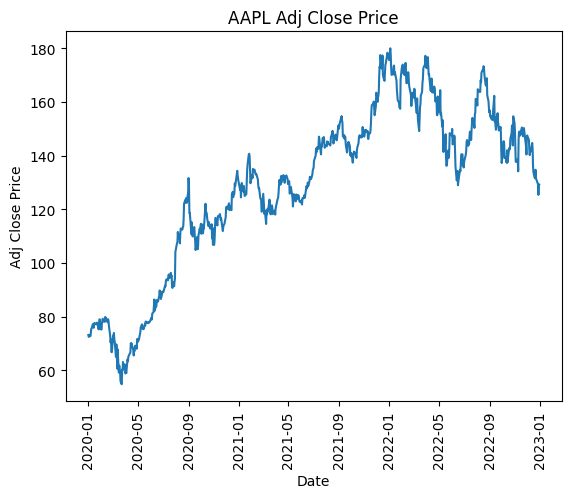

In [ ]:
# Create a line plot of the closing price
plt.plot(data['Adj Close'])

# Add axis labels and a title
plt.xlabel('Date')
plt.ylabel('Adj Close Price')
plt.title(stock_symbol + ' Adj Close Price')

# Rotate the x-axis labels to be vertical
plt.xticks(rotation=90)

# Show the plot
plt.show()

This will create a line plot of the closing price of the stock over time.

### ***Scatterplot***

Another type of plot that can be useful in stock price analysis is a scatter plot. A scatter plot allows you to visualize the relationship between two different variables, such as the closing price of a stock and its trading volume.

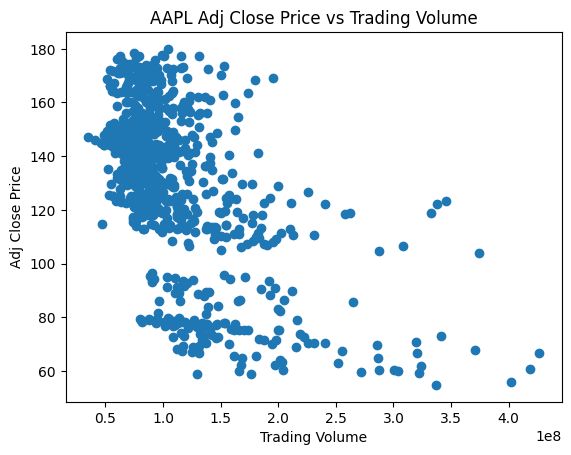

In [ ]:
# Create a scatter plot of the closing price against trading volume
plt.scatter(data['Volume'], data['Adj Close'])

# Add axis labels and a title
plt.xlabel('Trading Volume')
plt.ylabel('Adj Close Price')
plt.title(stock_symbol + ' Adj Close Price vs Trading Volume')

# Show the plot
plt.show()

This will create a scatter plot of the closing price of the stock against its trading volume. By looking at the scatter plot, you can identify any patterns or trends in the relationship between these two variables.

### ***Correlation and Covariance***
Correlation is a statistical measure that indicates the extent to which two or more variables fluctuate together. Covariance is a measure of the joint variability of two random variables. It is used to determine the direction of the linear relationship between two variables.

In [ ]:
# Calculate the correlation between 'Volume' and 'Adj Close' columns
correlation = data['Volume'].corr(data['Adj Close'])
print("Correlation between trading volume and closing price:", correlation)

# Calculate the covariance between 'Volume' and 'Adj Close' columns
covariance = data['Volume'].cov(data['Adj Close'])
print("Covariance between trading volume and closing price:", covariance)

Correlation between trading volume and closing price: -0.5683769047860794
Covariance between trading volume and closing price: -975829217.6526809


### ***Boxplot***

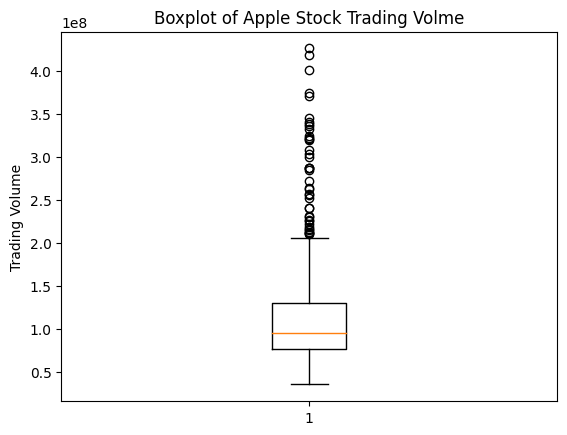

In [ ]:
# Create a boxplot of the "Volume" column in the DataFrame
plt.boxplot(data["Volume"])

# Add a title to the plot
plt.title("Boxplot of Apple Stock Trading Volme")

# Add a label to the y-axis
plt.ylabel("Trading Volume")

# Display the plot
plt.show()

### ***Bar chart***
Note that we are using seaborn library here.

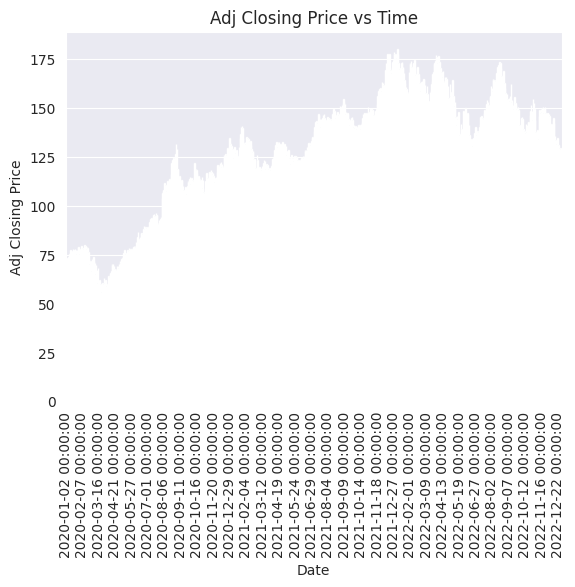

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# set the style of the plot
sns.set_style("darkgrid")

# create the barplot using Seaborn
sns.barplot(x=data.index, y="Adj Close", data=data)

# set the labels and title
plt.xlabel("Date")
plt.ylabel("Adj Closing Price")
plt.title("Adj Closing Price vs Time")

# set the tick frequency on the x-axis
tick_frequency = 25 # show one tick per month
plt.xticks(rotation=90)
plt.xticks(range(0, len(data.index), tick_frequency), data.index[::tick_frequency])

# display the plot
plt.show()


### ***Skewness***

Skewness is a measure of the asymmetry of a probability distribution of a real-valued random variable about its mean. It tells us if the data is symmetrical or if it is skewed to one side or the other.

We can use histogram or density plot to visualise the skewness of trading volume.

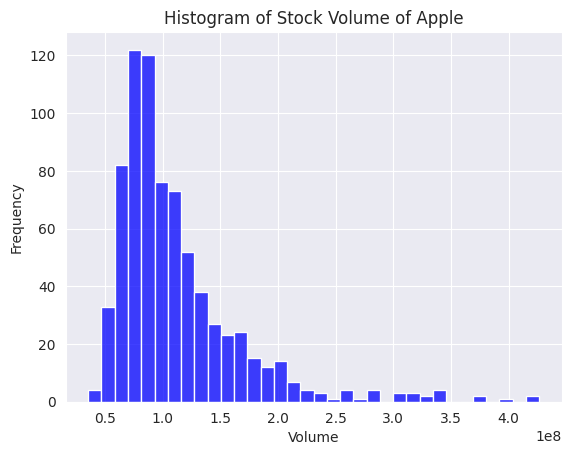

In [ ]:
import seaborn as sns

# Plot a histogram of the volume column to visualize the skewness
sns.histplot(data['Volume'], kde=False, color='blue')
plt.title('Histogram of Stock Volume of Apple')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

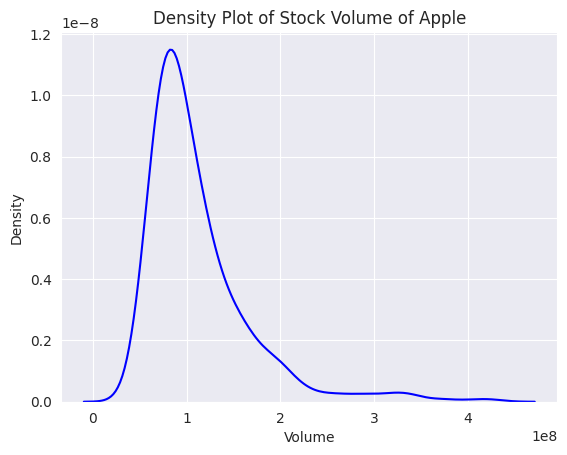

In [ ]:
# Plot a density plot of the volume column to visualize the skewness
sns.kdeplot(data['Volume'], color='blue')
plt.title('Density Plot of Stock Volume of Apple')
plt.xlabel('Volume')
plt.ylabel('Density')
plt.show()

## **Step 6: Analysis**

Once you have visualized your data, you can start performing some basic analysis. One way to analyze stock prices is by calculating the moving average. You will learn more about this in the next tutorial.

In [ ]:
short_window = 50
long_window = 200

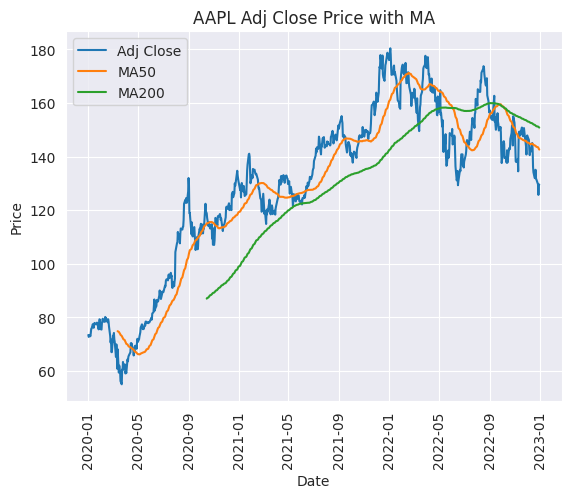

In [ ]:
# Calculate the 50-day moving average
MA50 = data['Adj Close'].rolling(window=short_window).mean()

# Calculate the 200-day moving average
MA200 = data['Adj Close'].rolling(window=long_window).mean()

# Add the moving averages to the dataframe
data['MA50'] = MA50
data['MA200'] = MA200

# Create a line plot of the closing price, 50-day moving average, and 200-day moving average
plt.plot(data['Adj Close'])
plt.plot(data['MA50'])
plt.plot(data['MA200'])

# Add axis labels, a legend, and a title
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(['Adj Close', 'MA50', 'MA200'])
plt.title(stock_symbol + ' Adj Close Price with MA')
plt.xticks(rotation=90)

# Show the plot
plt.show()

This will create a line plot with the closing price of the stock, as well as the moving averages of 50 days and 200 days. By comparing the moving averages, you can identify any trends or patterns in the stock price.

In [ ]:
data.head(1000)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400
2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441452,146322800
2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200
2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000
2020-01-08,74.290001,76.110001,74.290001,75.797501,73.844353,132079200
...,...,...,...,...,...,...
2022-12-23,130.919998,132.419998,129.639999,131.860001,131.127060,63814900
2022-12-27,131.380005,131.410004,128.720001,130.029999,129.307236,69007800
2022-12-28,129.669998,131.029999,125.870003,126.040001,125.339409,85438400


## **Conclusion**

As you can see, data visualization in Python is a powerful tool for understanding and communicating complex information. By using techniques like line plots, scatter plots, and moving averages, you can gain valuable insights into stock prices and make better investment decisions. Remember that practice and exploration with different stocks and different techniques will help you to become proficient in stock price analysis.